# Volatility Forecasting of S&P 500
**Objective:**

The goal of this analysis is to investigate the statistical properties fo equity returns, with a focus on volatility clustering and time-varying risk.

I aim to:
- Examine whether returns exhibit autocorrelation and whether their magnitude (squared returns) is predictable
- Validate key time-series properties such as stationarity and volatility clustering
- Compared realised volatility with implied volatility (VIX) to understand how market expectations align with observed market behaviour

Understanding these dynamcis is crucial for financial modeling, risk management, and volatility forecasting.

This analysis forms the foundation for applying volatility models such as ARIMA and GARCH in subsequent steps.

## Housekeeping

In [ ]:
# Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from volatility_forecasting.data.loader import download_price_data
from volatility_forecasting.features.preprocessing import compute_log_returns

In [52]:
# Set color palette to pastel and plot size
sns.set_theme(style="darkgrid")
plt.style.use("seaborn-v0_8-pastel")

plt.rcParams["figure.figsize"] = (15, 6)

## Data Sources
Data is sourced from Yahoo Finance via the yfinance API, which provides historical daily price data for financial indices.

In [53]:
# Download price data for S&P 500 and VIX and log transform prices

# SP500
sp500 = download_price_data("^GSPC")
sp500 = compute_log_returns(sp500)

# VIX
vix = download_price_data("^VIX")

In [54]:
# check for missing values
print("S&P 500 has missing values:", sp500.isnull().values.any())
print("VIX has missing values:", vix.isnull().values.any())

# check for missing date values
print("S&P 500 date range:", sp500.index.min(), "to", sp500.index.max())
print("VIX date range:", vix.index.min(), "to", vix.index.max())

S&P 500 has missing values: False
VIX has missing values: False
S&P 500 date range: 2000-01-04 00:00:00 to 2026-03-10 00:00:00
VIX date range: 2000-01-03 00:00:00 to 2026-03-10 00:00:00


## Visualizations

#### Prices vs Returns

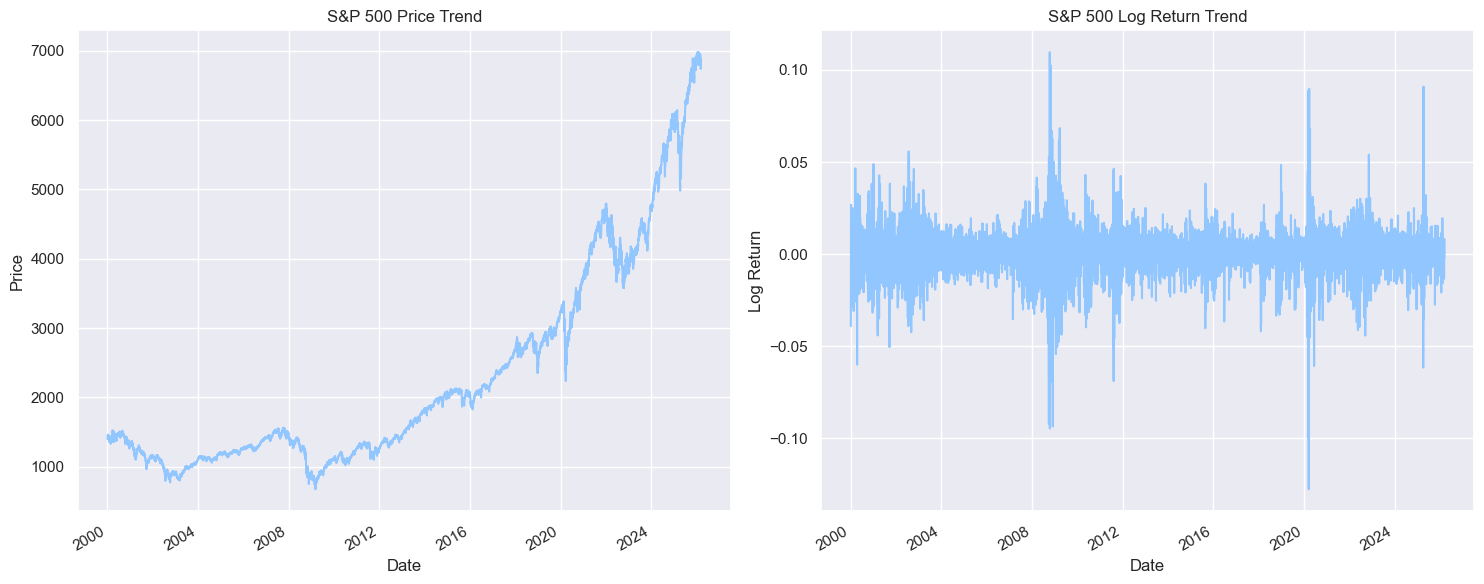

In [55]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 6))

# plot the price and log return trends for S&P 500
sp500["price"].plot(ax=ax[0], title="S&P 500 Price Trend", ylabel="Price")
sp500["log_return"].plot(ax=ax[1], title="S&P 500 Log Return Trend", ylabel="Log Return")

plt.tight_layout()

#### Volatility Clustering

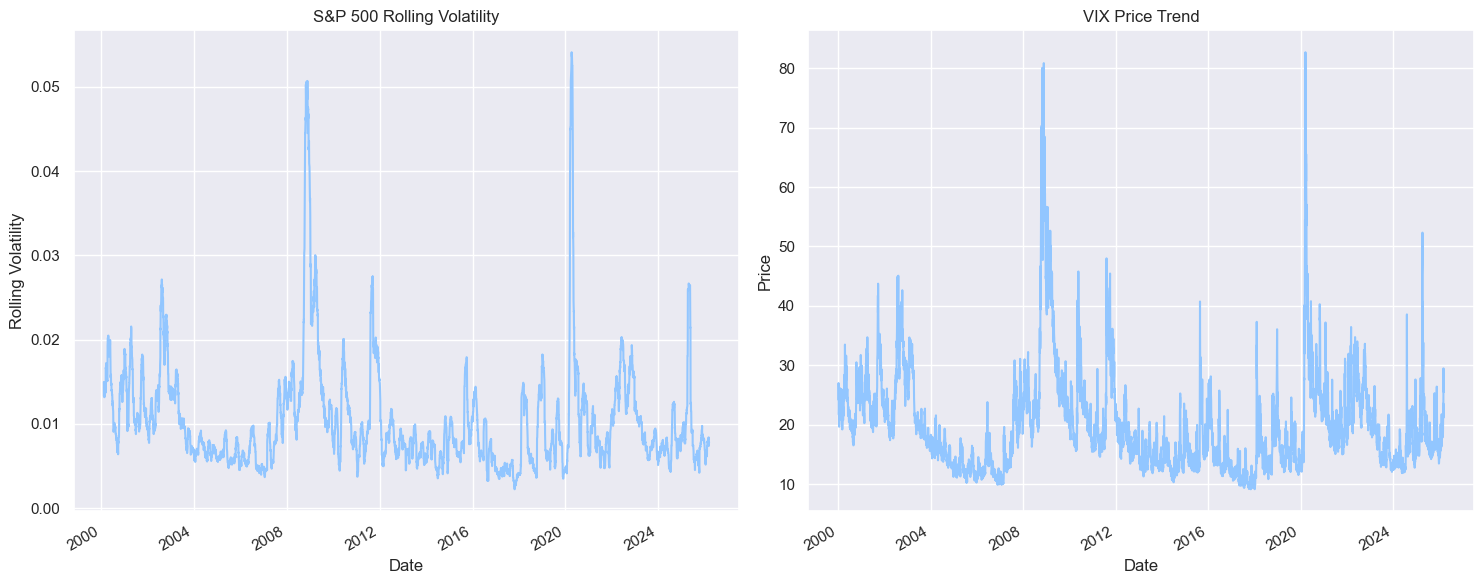

In [45]:
# plot 30-day rolling volatility for S&P 500 to identify periods of high volatility and potential regime shifts
# expectations - clustering, crisis spikes, regime shifts

rolling_window = 30
sp500["rolling_volatility"] = sp500["log_return"].rolling(window=rolling_window).std()

fig, ax = plt.subplots(ncols=2, figsize=(15, 6))
sp500["rolling_volatility"].plot(ax=ax[0], title="S&P 500 Rolling Volatility", ylabel="Rolling Volatility")
vix["price"].plot(ax=ax[1], title="VIX Price Trend", ylabel="Price")
plt.tight_layout()
plt.show()

#### Volatility is the lowest right before it spikes
- S&P 500 prices exhibit a long-term upward trend and changing variances, indicating non-stationarity in both mean and variance
- Rolling volatility shows clear clustering, where periods of high volatility are followed by high volatility and calm periods by calm conditions. This indicates persistence in volatility over time.
- Volatility is mean-reverting, where extreme spikes (eg high VIX levels) are typically followed by a gradual decline toward normal levels.

- Volatility spikes align with VIX spikes
- Volatility stays high after crises -> volatility clustering
    - Markets dont calm down immediately after panic -> fear decays slowly
- Calm periods are long; crises short
    - Markets are calm most of the time but extreme events dominate risk
- Volatility spikes harder, increases less (negative peaks have greater magnitude than positive ones)

## Stationarity and Autocorrelation

#### Autocorrelation - ACF Plots

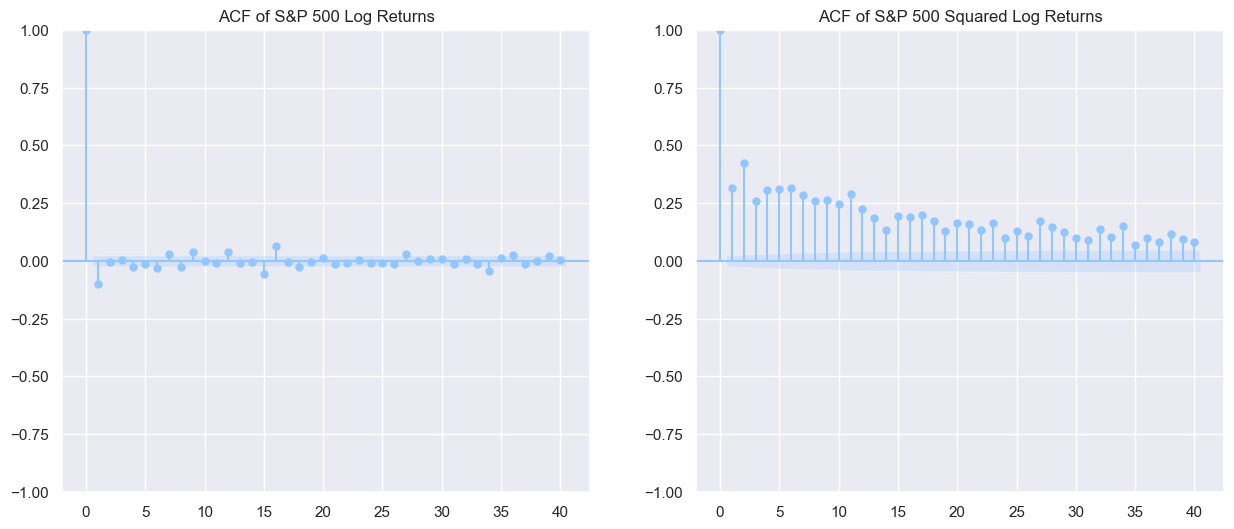

In [ ]:
# plot acf on log returns and log returns squared to check for stationarity and seasonality next to each other
fig, ax = plt.subplots(ncols=2, figsize=(15, 6))
log_return_acf = plot_acf(sp500["log_return"], lags=40, ax=ax[0], title="ACF of S&P 500 Log Returns")
squared_log_return_acf = plot_acf(sp500["log_return"] ** 2, lags=40, ax=ax[1], title="ACF of S&P 500 Squared Log Returns")

- Significant spikes at multiple lags for squared returns

The ACF of returns is close to zero, indicating little linear predictability in returns. However, the ACF of the squared returns shows significant persistence across lags, which suggests volatility clustering. This implies that while retuns themselves are largely unpredictable, their variance is predictable, motivating the use of models like GARCH.

#### Stationarity - ADF Tests

In [51]:
# ADF test for stationarity price levels
adf_price = adfuller(sp500["price"].dropna())

# Print ADF test results for price levels
print("ADF Test on Price Levels:")
print("ADF Statistic:", adf_price[0])
print("p-value:", adf_price[1])
print("Critical Values:", adf_price[4])

ADF Test on Price Levels:
ADF Statistic: 2.6040221656706657
p-value: 0.9990758882549525
Critical Values: {'1%': -3.431347995826383, '5%': -2.8619810292678873, '10%': -2.567004756449709}


The ADF test fails to reject the null hypothesis of a unit root, indicating that prices are non-stationary and follow a stochastic trend.

In [ ]:
# ADF test for stationarity log returns

adf_log_return = adfuller(sp500["log_return"].dropna())

# print ADF test results
print("ADF Test on Log Returns:")
print("ADF Statistic:", adf_log_return[0])
print("p-value:", adf_log_return[1])
print("Critical Values:", adf_log_return[4])

ADF Test on Log Returns:
ADF Statistic: -19.54766732919849
p-value: 0.0
Critical Values: {'1%': -3.4313463232326624, '5%': -2.8619802902476055, '10%': -2.567004363053599}


The ADF test strongly rejects the null hypothesis of a unit root, suggesting that log returns are stationary.

RETURNS ARE CONDITIONALLY HETEROSKEDASTIC

-> If returns are stationary, can we model them using past values?

## Key Findings
- Returns show no autocorrelation
- Squared returns show strong autocorrelation -> volatility clustering
- Prices are non-stationary, returns are stationary
- VIX closely tracks realised volaitlity

## Next Steps
- Fit ARIMA
- Fit GARCH